In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset




In [2]:
df1=pd.read_csv(r"inputdata/EVUsersChargingData-high.csv")
df2=pd.read_csv(r"inputdata/EVUsersChargingData-low.csv")
df=pd.concat([df1, df2], ignore_index=True)

In [3]:
df.head()

,No.,ArriveTime,DepartTime,Duration/min,ArriveSOC,DepartSOC,BatteryCapacity/kWh,Fast-chargingWillingness,DischargingWillingness,AverageChargingPower
0,1,05:27,06:27,60,0.4800,0.9,50,1,0.123598,21.000000
1,2,05:44,06:30,46,0.4440,0.9,40,1,0.457124,23.791304
2,3,05:47,06:47,60,0.4957,0.9,40,1,0.281148,16.170000
3,4,06:05,06:52,47,0.4367,0.9,40,1,0.287219,23.655319
4,5,06:07,08:48,161,0.4867,0.9,60,1,0.261950,9.242236


In [4]:

df.tail()

,No.,ArriveTime,DepartTime,Duration/min,ArriveSOC,DepartSOC,BatteryCapacity/kWh,Fast-chargingWillingness,DischargingWillingness,AverageChargingPower
1995,996,21:30,23:59,149,0.4880,0.9,40,1,0.634238,6.636242
1996,997,21:33,23:45,132,0.4707,0.9,60,1,0.466063,11.707727
1997,998,22:27,23:12,45,0.4727,0.9,40,1,0.069011,22.792000
1998,999,22:35,02:27,232,0.4966,0.9,50,1,0.535844,5.216379
1999,1000,23:16,03:40,264,0.4411,0.9,40,1,0.637081,4.171818


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   No.                       2000 non-null   int64  
 1   ArriveTime                2000 non-null   object 
 2   DepartTime                2000 non-null   object 
 3   Duration/min              2000 non-null   int64  
 4   ArriveSOC                 2000 non-null   float64
 5   DepartSOC                 2000 non-null   float64
 6   BatteryCapacity/kWh       2000 non-null   int64  
 7   Fast-chargingWillingness  2000 non-null   int64  
 8   DischargingWillingness    2000 non-null   float64
 9   AverageChargingPower      2000 non-null   float64
dtypes: float64(4), int64(4), object(2)
memory usage: 156.4+ KB


In [6]:
def time_to_float(t):
    hour, minute = map(int, t.split(":"))
    return hour + minute / 60



df['ArriveTime_float'] = df['ArriveTime'].apply(time_to_float)
df['DepartTime_float'] = df['DepartTime'].apply(time_to_float)

df['Arrive_sin'] = np.sin(2 * np.pi * df['ArriveTime_float'] / 24)
df['Arrive_cos'] = np.cos(2 * np.pi * df['ArriveTime_float'] / 24)
df['Depart_sin'] = np.sin(2 * np.pi * df['DepartTime_float'] / 24)
df['Depart_cos'] = np.cos(2 * np.pi * df['DepartTime_float'] / 24)

features=["Arrive_sin","Arrive_cos","Depart_sin",'Depart_cos',"Duration/min","ArriveSOC","DepartSOC","BatteryCapacity/kWh","Fast-chargingWillingness","DischargingWillingness"]
target=["AverageChargingPower"]

df_features=df[features]
df_target=df[target]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.2, random_state=42)


# Normalize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

if len(y_train.shape) == 1:
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
else:

    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

if len(y_test.shape) == 1:
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)
else:
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size)



In [9]:

input_channels = X_train_tensor.shape[1]
sequence_length = X_train_tensor.shape[2]

class CNN1DRegression(nn.Module):
    def __init__(self, input_features=input_channels, output_classes=1, sequence_length=sequence_length):
        super(CNN1DRegression, self).__init__()


        self.conv1 = nn.Conv1d(in_channels=input_features, out_channels=16, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)

        with torch.no_grad():
            dummy_input = torch.randn(1, input_features, sequence_length)
            dummy_output = self.pool1(self.relu1(self.conv1(dummy_input)))
            dummy_output = self.pool2(self.relu2(self.conv2(dummy_output)))
            flattened_size = dummy_output.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, output_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.fc1(x)
        output = self.fc2(x)
        return output

In [18]:
#pick random seed for reproducibility
torch.manual_seed(0)
model = CNN1DRegression()


In [19]:
#set criteria of model to measure error.. how far off the prediction are from data
criterion = nn.MSELoss()
#choose optimizer we use Adam Optimizer
#learning rate (if error doesn't go down after bunch of epochs we might want to lower the learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [20]:
#train model

losses = []
rs=[]
#decide how many epochs we want to train the model
epochs = 20

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    epoch_r2=0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        r2 = r2_score(y_batch.detach().cpu().numpy(), output.detach().cpu().numpy())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_r2 += r2



    avg_loss = epoch_loss / len(train_loader)
    avg_r2=epoch_r2 / len(train_loader)
    rs.append(avg_r2)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
    print(f"Epoch {epoch+1}/{epochs} - R2: {avg_r2:.4f}")


Epoch 1/20 - Loss: 51.4646
Epoch 1/20 - R2: 0.0673
Epoch 2/20 - Loss: 15.5860
Epoch 2/20 - R2: 0.7096
Epoch 3/20 - Loss: 8.2876
Epoch 3/20 - R2: 0.8460
Epoch 4/20 - Loss: 3.3872
Epoch 4/20 - R2: 0.9380
Epoch 5/20 - Loss: 2.2098
Epoch 5/20 - R2: 0.9591
Epoch 6/20 - Loss: 1.6607
Epoch 6/20 - R2: 0.9692
Epoch 7/20 - Loss: 1.4422
Epoch 7/20 - R2: 0.9735
Epoch 8/20 - Loss: 1.2447
Epoch 8/20 - R2: 0.9770
Epoch 9/20 - Loss: 1.0223
Epoch 9/20 - R2: 0.9813
Epoch 10/20 - Loss: 0.8803
Epoch 10/20 - R2: 0.9839
Epoch 11/20 - Loss: 0.8989
Epoch 11/20 - R2: 0.9834
Epoch 12/20 - Loss: 1.0548
Epoch 12/20 - R2: 0.9804
Epoch 13/20 - Loss: 1.8116
Epoch 13/20 - R2: 0.9668
Epoch 14/20 - Loss: 1.0382
Epoch 14/20 - R2: 0.9808
Epoch 15/20 - Loss: 0.8379
Epoch 15/20 - R2: 0.9848
Epoch 16/20 - Loss: 0.7698
Epoch 16/20 - R2: 0.9859
Epoch 17/20 - Loss: 0.9612
Epoch 17/20 - R2: 0.9822
Epoch 18/20 - Loss: 1.2110
Epoch 18/20 - R2: 0.9773
Epoch 19/20 - Loss: 0.6753
Epoch 19/20 - R2: 0.9875
Epoch 20/20 - Loss: 0.6798
E

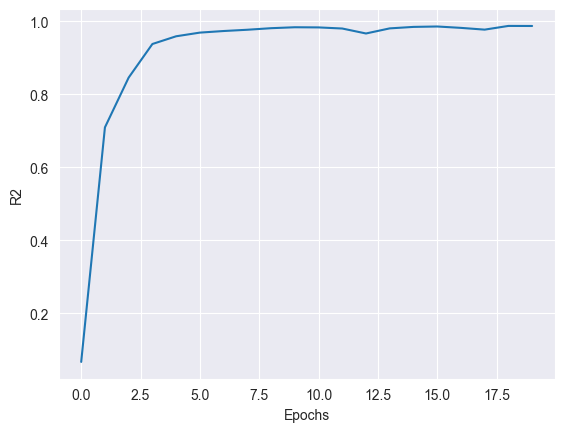

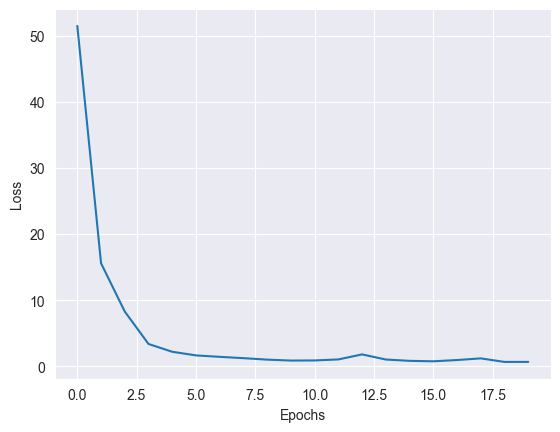

In [21]:
#graph
plt.plot(range(epochs), rs)
plt.xlabel('Epochs')
plt.ylabel('R2')
plt.show()

plt.plot(range(epochs), losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [22]:
model.eval()

y_preds = []
y_trues = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        y_preds.append(y_pred.cpu().numpy())
        y_trues.append(y_batch.cpu().numpy())

# Concatenate all batches
y_pred = np.concatenate(y_preds, axis=0)
y_true = np.concatenate(y_trues, axis=0)


In [23]:
#EVALUATING MODEL

# Compute metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print(f"Evaluation Metrics:")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"MSE  (Mean Squared Error): {mse:.4f}")
print(f"RMSE (Root MSE):            {rmse:.4f}")
print(f"R²   (R-squared):           {r2:.4f}")

Evaluation Metrics:
MAE  (Mean Absolute Error): 0.5534
MSE  (Mean Squared Error): 0.5893
RMSE (Root MSE):            0.7676
R²   (R-squared):           0.9896
